In [ ]:
!pip uninstall tensorflow

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model, layers

ImportError: Traceback (most recent call last):
  File "C:\Users\plane\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 70, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: DLL 초기화 루틴을 실행할 수 없습니다.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [47]:
tf.__version__

'2.18.0'

In [5]:
random.seed(1)
np.random.seed(1)
tf.random.set_seed(1)

In [7]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

In [9]:
(x_train_val, y_train_val),(x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train, x_valid, y_train, y_valid = train_test_split(x_train_val, y_train_val, test_size= 0.2, shuffle=True, stratify = y_train_val, random_state=34)

print(x_train.shape) #=> (48000, 28, 28) 
print(y_train.shape) #=> (48000,)
print(x_train[0].shape) #=> (28, 28) 이미지 한장 크기

print(x_valid.shape) #=> (12000, 28, 28)
print(x_test.shape) #=> (10000, 28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(48000, 28, 28)
(48000,)
(28, 28)
(12000, 28, 28)
(10000, 28, 28)


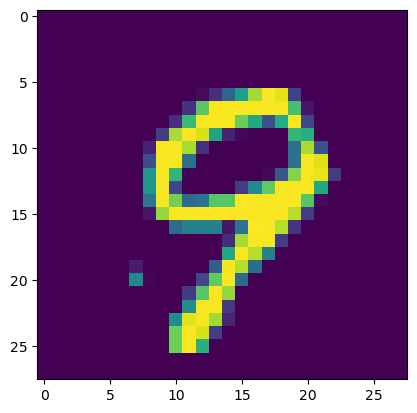

In [11]:
plt.imshow(x_train[1])
plt.show()

In [13]:
num_classes = len(set(y_train)) # MNIST는 10개의 class를 가진다.
print(num_classes) #=> 10

10


In [15]:
# Scale to [0,1]
x_train = x_train.astype('float32') / 255
x_valid = x_valid.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [17]:
# input shape: (data수, image_width, image_height, channel_num)
image_w, image_h = x_train.shape[1], x_train.shape[2]

x_train = x_train.reshape(-1, image_w, image_h, 1)
x_valid = x_valid.reshape(-1, image_w, image_h, 1)
x_test = x_test.reshape(-1, image_w, image_h, 1)

print(x_train.shape, x_valid.shape, x_test.shape) 
#=> (48000, 28, 28, 1) (12000, 28, 28, 1) (10000, 28, 28, 1)
print(y_train.shape, y_valid.shape, y_test.shape) 
#=> (48000,) (12000,) (10000,)

(48000, 28, 28, 1) (12000, 28, 28, 1) (10000, 28, 28, 1)
(48000,) (12000,) (10000,)


In [37]:
# layers.Conv2D( 생성할 커널수, 커널사이즈, 커널이동거리, 패딩방법지정, 활성화함수지정, 입력데이터 차원정보(첫레이어일때만) )
# layers.MaxPool2D( 커널사이즈, 커널이동거리, 패딩방법지정 )
# layers.Dense( 노드수, 활성화함수지정 )

import tensorflow as tf
from tensorflow.keras import layers, Model

class CNN(Model):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(28,28,1))
        self.maxpool1 = layers.MaxPool2D((3,3), strides=2, padding='same')
        
        self.conv2 = layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu')
        self.maxpool2 = layers.MaxPool2D((3,3), strides=2, padding='same')
        
        self.flatten = layers.Flatten()
        self.fc1 = layers.Dense(128, activation='relu')
        self.fc2 = layers.Dense(num_classes, activation='softmax')  # num_classes 반영

    def call(self, x):
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x


In [39]:
# 예제: 10개의 클래스를 분류하는 CNN 모델 생성
num_classes = 10
cnn = CNN(num_classes)

In [41]:
cnn.compile(loss = 'sparse_categorical_crossentropy', 
            optimizer = tf.keras.optimizers.SGD(learning_rate=0.1), 
            metrics = ['accuracy'])

In [43]:
history = cnn.fit(x_train, y_train,
                  epochs=5, # 반복학습 횟수
                  batch_size=128, # 1epoch에 모든 데이터를 한번에 돌리는게 아닌, batch로 나누어 돌림
                  validation_data=(x_test, y_test)) # 검증셋

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7162 - loss: 0.8743 - val_accuracy: 0.9669 - val_loss: 0.1031
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9652 - loss: 0.1073 - val_accuracy: 0.9783 - val_loss: 0.0669
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9764 - loss: 0.0735 - val_accuracy: 0.9833 - val_loss: 0.0529
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9821 - loss: 0.0567 - val_accuracy: 0.9849 - val_loss: 0.0450
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9860 - loss: 0.0457 - val_accuracy: 0.9865 - val_loss: 0.0395


In [49]:
history.history

{'accuracy': [0.8704166412353516,
  0.9701250195503235,
  0.9785833358764648,
  0.9835416674613953,
  0.9865208268165588],
 'loss': [0.4065368175506592,
  0.09487753361463547,
  0.06740766763687134,
  0.05307978764176369,
  0.04362499341368675],
 'val_accuracy': [0.9668999910354614,
  0.9782999753952026,
  0.983299970626831,
  0.9848999977111816,
  0.9865000247955322],
 'val_loss': [0.10306227952241898,
  0.06692144274711609,
  0.05292586609721184,
  0.0450013130903244,
  0.039495691657066345]}

In [51]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9838 - loss: 0.0472


[0.039495691657066345, 0.9865000247955322]